In [1]:
!pip -q install scikit-learn

import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
IMG_SIZE = 64
CHANNELS = 1
BATCH_SIZE = 32
AE_LATENT_DIM = 32
VAE_LATENT_DIM = 3
EPOCHS_AE = 10
EPOCHS_VAE = 10
EPOCHS_DENOISING = 5

SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/DSAI490/medical-mnist/archive.zip"
extract_path = "/content/medical_mnist"

os.makedirs(extract_path, exist_ok=True)

if len(os.listdir(extract_path)) == 0:
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)
print("Dataset folders:", os.listdir(extract_path))

Mounted at /content/drive
Dataset extracted to: /content/medical_mnist
Dataset folders: ['HeadCT', 'BreastMRI', 'ChestCT', 'AbdomenCT', 'CXR', 'Hand']


In [4]:
def collect_image_paths_and_labels(root_dir):
    class_names = sorted([
        folder for folder in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, folder))
    ])

    image_paths = []
    labels = []

    valid_extensions = (".png", ".jpg", ".jpeg", ".bmp")

    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(root_dir, class_name)

        for filename in os.listdir(class_folder):
            if filename.lower().endswith(valid_extensions):
                image_paths.append(os.path.join(class_folder, filename))
                labels.append(label)

    image_paths = np.array(image_paths)
    labels = np.array(labels)

    return image_paths, labels, class_names


image_paths, labels, class_names = collect_image_paths_and_labels(extract_path)

print("Total images:", len(image_paths))
print("Number of classes:", len(class_names))
print("Classes:", class_names)

Total images: 58954
Number of classes: 6
Classes: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']


In [5]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))

Training images: 47163
Validation images: 11791


In [6]:
def load_image(path, label):
    img = tf.io.read_file(path)

    img = tf.image.decode_image(
        img,
        channels=CHANNELS,
        expand_animations=False
    )

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    label = tf.cast(label, tf.int32)

    return img, label


def make_reconstruction_dataset(paths, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    # For AE/VAE reconstruction: input image = target image
    ds = ds.map(lambda img, label: (img, img), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds


def make_labeled_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds


train_ds = make_reconstruction_dataset(train_paths, train_labels, training=True)
val_ds = make_reconstruction_dataset(val_paths, val_labels, training=False)

train_labeled_ds = make_labeled_dataset(train_paths, train_labels, training=False)
val_labeled_ds = make_labeled_dataset(val_paths, val_labels, training=False)

print("tf.data pipelines are ready.")

tf.data pipelines are ready.


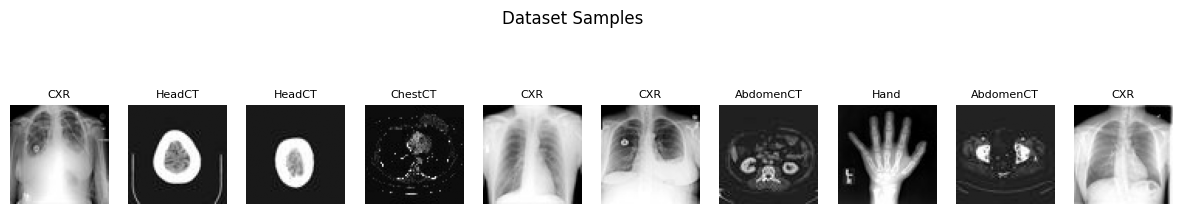

In [7]:
def show_dataset_samples(dataset, class_names, n=10):
    images, labels_batch = next(iter(dataset))

    plt.figure(figsize=(15, 3))

    for i in range(min(n, len(images))):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(class_names[int(labels_batch[i])], fontsize=8)
        plt.axis("off")

    plt.suptitle("Dataset Samples")
    plt.show()


show_dataset_samples(train_labeled_ds, class_names, n=10)

In [8]:
def create_autoencoder(latent_dim=32):
    # Encoder
    encoder_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS), name="ae_encoder_input")

    x = layers.Conv2D(32, kernel_size=3, strides=2, padding="same", activation="relu")(encoder_input)
    x = layers.Conv2D(64, kernel_size=3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, kernel_size=3, strides=2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)

    latent = layers.Dense(latent_dim, name="ae_latent_vector")(x)

    encoder = Model(encoder_input, latent, name="AE_Encoder")

    # Decoder
    decoder_input = layers.Input(shape=(latent_dim,), name="ae_decoder_input")

    x = layers.Dense(8 * 8 * 128, activation="relu")(decoder_input)
    x = layers.Reshape((8, 8, 128))(x)
    x = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding="same", activation="relu")(x)

    decoder_output = layers.Conv2D(
        CHANNELS,
        kernel_size=3,
        padding="same",
        activation="sigmoid",
        name="ae_reconstruction"
    )(x)

    decoder = Model(decoder_input, decoder_output, name="AE_Decoder")

    # AE
    ae_input = encoder_input
    ae_output = decoder(encoder(ae_input))

    autoencoder = Model(ae_input, ae_output, name="Autoencoder")

    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="mse",
        metrics=["mse"]
    )

    return autoencoder, encoder, decoder


ae, ae_encoder, ae_decoder = create_autoencoder(AE_LATENT_DIM)

ae.summary()
ae_encoder.summary()
ae_decoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_encoder_input (InputLayer)   │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AE_Encoder (Functional)         │ (None, 32)             │       354,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AE_Decoder (Functional)         │ (None, 64, 64, 1)      │       510,465 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865,313 (3.30 MB)

 Trainable params: 865,313 (3.30 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "AE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_decoder_input (InputLayer)   │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8192)           │       270,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_reconstruction (Conv2D)      │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 510,465 (1.95 MB)

 Trainable params: 510,465 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [10]:
def create_vae(latent_dim=3):
    # Encoder
    encoder_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS), name="vae_encoder_input")

    x = layers.Conv2D(32, kernel_size=3, strides=2, padding="same", activation="relu")(encoder_input)
    x = layers.Conv2D(64, kernel_size=3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, kernel_size=3, strides=2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling(name="z_sampling")([z_mean, z_log_var])

    encoder = Model(
        encoder_input,
        [z_mean, z_log_var, z],
        name="VAE_Encoder"
    )

    # Decoder
    decoder_input = layers.Input(shape=(latent_dim,), name="vae_decoder_input")

    x = layers.Dense(8 * 8 * 128, activation="relu")(decoder_input)
    x = layers.Reshape((8, 8, 128))(x)
    x = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding="same", activation="relu")(x)

    decoder_output = layers.Conv2D(
        CHANNELS,
        kernel_size=3,
        padding="same",
        activation="sigmoid",
        name="vae_reconstruction"
    )(x)

    decoder = Model(decoder_input, decoder_output, name="VAE_Decoder")

    return encoder, decoder


class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def compute_vae_loss(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.square(x - reconstruction),
                axis=[1, 2, 3]
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + kl_loss

        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self.compute_vae_loss(x)

        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        total_loss, reconstruction_loss, kl_loss = self.compute_vae_loss(x)

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }


vae_encoder, vae_decoder = create_vae(VAE_LATENT_DIM)
vae = VAE(vae_encoder, vae_decoder, name="Variational_Autoencoder")

vae.compile(optimizer=tf.keras.optimizers.Adam())

vae_encoder.summary()
vae_decoder.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │        320 │ vae_encoder_inpu… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     18,496 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8192)      │          0 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 3)         │     24,579 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 3)         │     24,579 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_sampling          │ (None, 3)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 141,830 (554.02 KB)

 Trainable params: 141,830 (554.02 KB)

 Non-trainable params: 0 (0.00 B)

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vae_decoder_input (InputLayer)  │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8192)           │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_reconstruction (Conv2D)     │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,897 (1.04 MB)

 Trainable params: 272,897 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
ae_history = ae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_AE
)

Epoch 1/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 45s 15ms/step - loss: 0.0122 - mse: 0.0122 - val_loss: 0.0070 - val_mse: 0.0070
Epoch 2/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0064 - mse: 0.0064 - val_loss: 0.0060 - val_mse: 0.0060
Epoch 3/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - loss: 0.0057 - mse: 0.0057 - val_loss: 0.0056 - val_mse: 0.0056
Epoch 4/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 0.0053 - mse: 0.0053 - val_loss: 0.0052 - val_mse: 0.0052
Epoch 5/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0050 - mse: 0.0050 - val_loss: 0.0051 - val_mse: 0.0051
Epoch 6/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.0048 - mse: 0.0048 - val_loss: 0.0049 - val_mse: 0.0049
Epoch 7/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0047 - mse: 0.0047 - val_loss: 0.0048 - val_mse: 0.0048
Epoch 8/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.0045 - mse: 0.0045 - val_loss: 0.0048 - val_mse: 0.0048
Epoch 9/10
1474/1474 ━━━

In [12]:
vae_history = vae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_VAE
)

Epoch 1/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - kl_loss: 6.9106 - loss: 106.2743 - reconstruction_loss: 99.3636 - val_kl_loss: 7.1136 - val_loss: 82.7976 - val_reconstruction_loss: 75.6841
Epoch 2/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - kl_loss: 7.4463 - loss: 80.4977 - reconstruction_loss: 73.0514 - val_kl_loss: 7.4773 - val_loss: 78.6224 - val_reconstruction_loss: 71.1452
Epoch 3/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - kl_loss: 7.5590 - loss: 77.0885 - reconstruction_loss: 69.5295 - val_kl_loss: 8.0481 - val_loss: 76.5455 - val_reconstruction_loss: 68.4974
Epoch 4/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - kl_loss: 7.6157 - loss: 75.2361 - reconstruction_loss: 67.6204 - val_kl_loss: 7.8255 - val_loss: 74.7954 - val_reconstruction_loss: 66.9699
Epoch 5/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - kl_loss: 7.6615 - loss: 74.0049 - reconstruction_loss: 66.3434 - val_kl_loss: 7.5500 - val_loss: 74.5658 - val_reconstruction_loss: 67.0157
Epoch 6/1

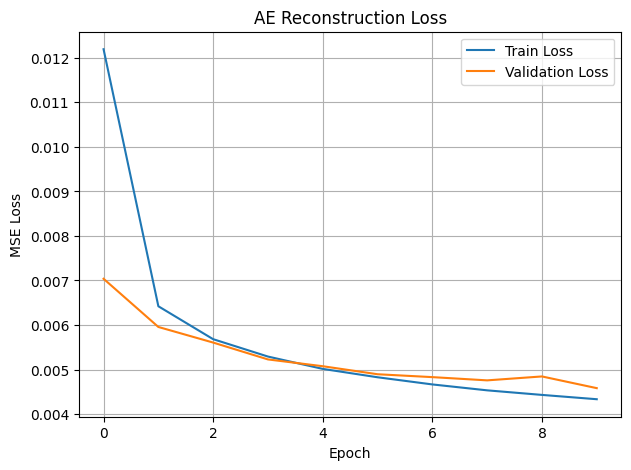

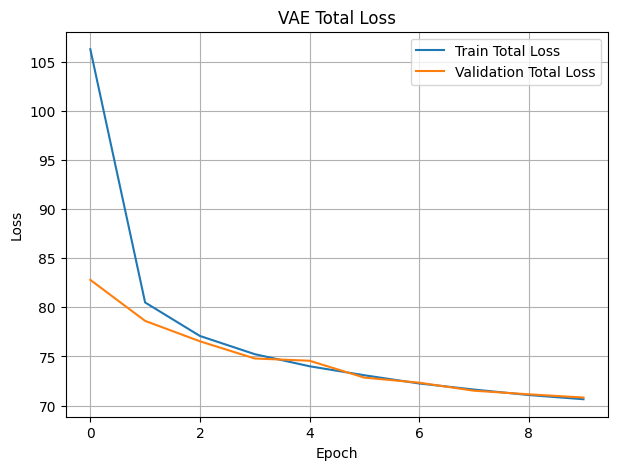

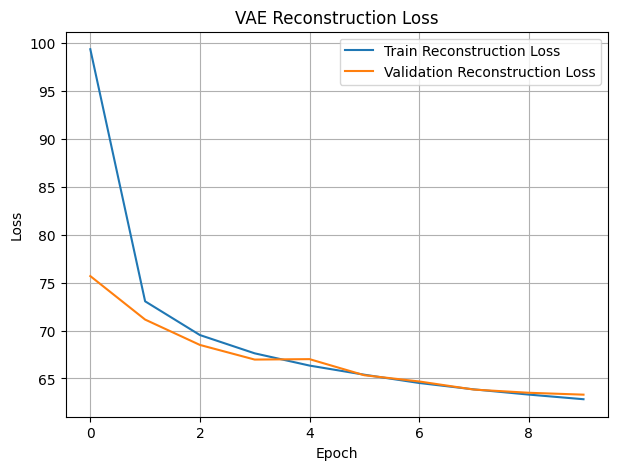

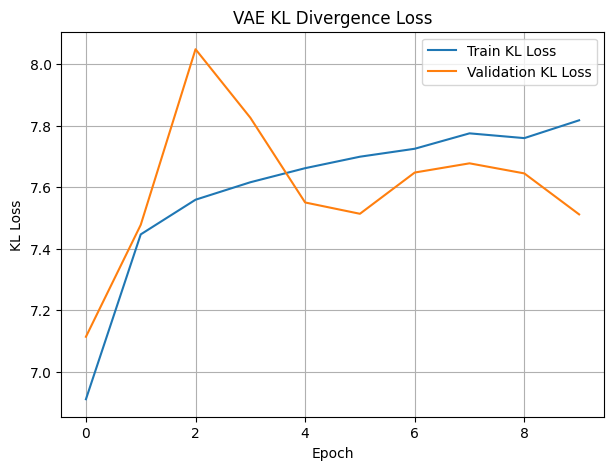

In [13]:
def plot_ae_loss(history):
    plt.figure(figsize=(7, 5))

    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")

    plt.title("AE Reconstruction Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_vae_losses(history):
    plt.figure(figsize=(7, 5))
    plt.plot(history.history["loss"], label="Train Total Loss")
    plt.plot(history.history["val_loss"], label="Validation Total Loss")
    plt.title("VAE Total Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history.history["reconstruction_loss"], label="Train Reconstruction Loss")
    plt.plot(history.history["val_reconstruction_loss"], label="Validation Reconstruction Loss")
    plt.title("VAE Reconstruction Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history.history["kl_loss"], label="Train KL Loss")
    plt.plot(history.history["val_kl_loss"], label="Validation KL Loss")
    plt.title("VAE KL Divergence Loss")
    plt.xlabel("Epoch")
    plt.ylabel("KL Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_ae_loss(ae_history)
plot_vae_losses(vae_history)

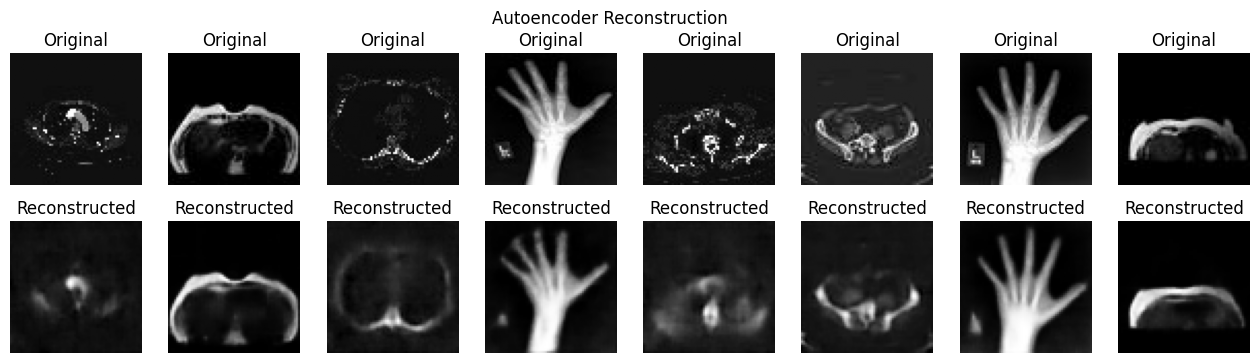

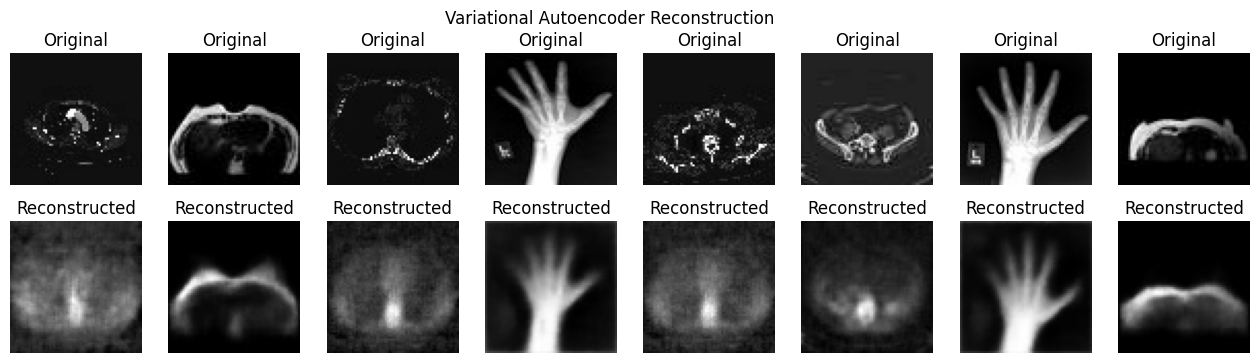

In [14]:
def show_reconstruction(model, dataset, title, n=8):
    x_batch, _ = next(iter(dataset))
    recon = model.predict(x_batch, verbose=0)

    plt.figure(figsize=(2 * n, 4))

    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(x_batch[i].numpy().squeeze(), cmap="gray")
        plt.title("Original")
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(recon[i].squeeze(), cmap="gray")
        plt.title("Reconstructed")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()


show_reconstruction(ae, val_ds, "Autoencoder Reconstruction", n=8)
show_reconstruction(vae, val_ds, "Variational Autoencoder Reconstruction", n=8)

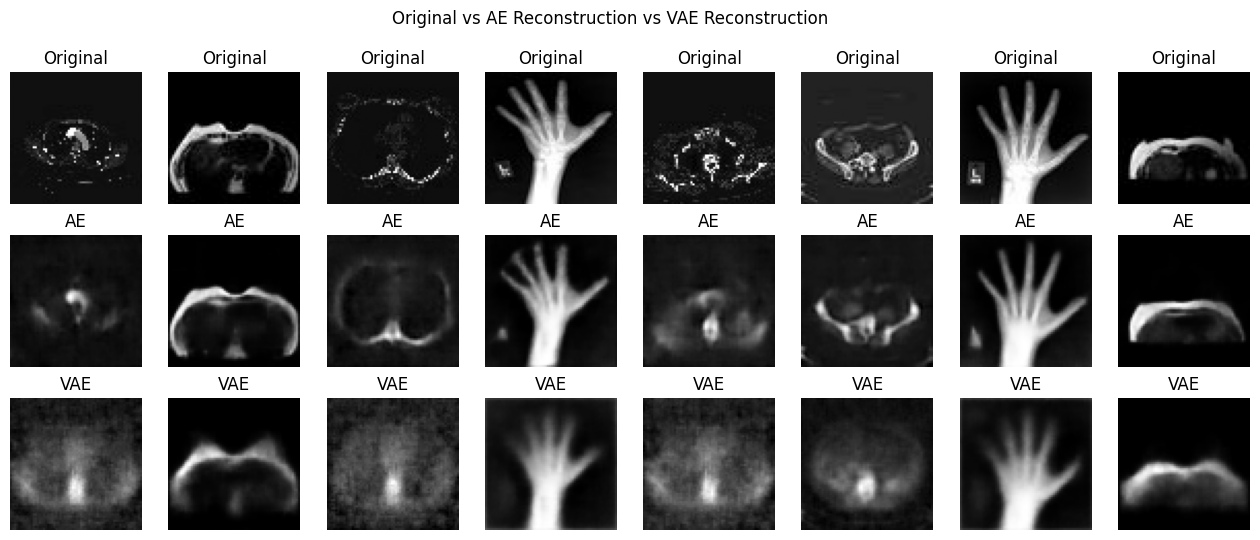

In [15]:
def compare_ae_vae(ae_model, vae_model, dataset, n=8):
    x_batch, _ = next(iter(dataset))

    ae_recon = ae_model.predict(x_batch, verbose=0)
    vae_recon = vae_model.predict(x_batch, verbose=0)

    plt.figure(figsize=(2 * n, 6))

    for i in range(n):
        plt.subplot(3, n, i + 1)
        plt.imshow(x_batch[i].numpy().squeeze(), cmap="gray")
        plt.title("Original")
        plt.axis("off")

        plt.subplot(3, n, i + 1 + n)
        plt.imshow(ae_recon[i].squeeze(), cmap="gray")
        plt.title("AE")
        plt.axis("off")

        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(vae_recon[i].squeeze(), cmap="gray")
        plt.title("VAE")
        plt.axis("off")

    plt.suptitle("Original vs AE Reconstruction vs VAE Reconstruction")
    plt.show()


compare_ae_vae(ae, vae, val_ds, n=8)

In [16]:
def evaluate_reconstruction_quality(ae_model, vae_model, dataset):
    ae_mse_values = []
    vae_mse_values = []

    ae_ssim_values = []
    vae_ssim_values = []

    for x_batch, _ in dataset:
        ae_recon = ae_model.predict(x_batch, verbose=0)
        vae_recon = vae_model.predict(x_batch, verbose=0)

        ae_mse = tf.reduce_mean(tf.square(x_batch - ae_recon), axis=[1, 2, 3])
        vae_mse = tf.reduce_mean(tf.square(x_batch - vae_recon), axis=[1, 2, 3])

        ae_ssim = tf.image.ssim(x_batch, ae_recon, max_val=1.0)
        vae_ssim = tf.image.ssim(x_batch, vae_recon, max_val=1.0)

        ae_mse_values.extend(ae_mse.numpy())
        vae_mse_values.extend(vae_mse.numpy())

        ae_ssim_values.extend(ae_ssim.numpy())
        vae_ssim_values.extend(vae_ssim.numpy())

    results = {
        "AE MSE": np.mean(ae_mse_values),
        "VAE MSE": np.mean(vae_mse_values),
        "AE SSIM": np.mean(ae_ssim_values),
        "VAE SSIM": np.mean(vae_ssim_values)
    }

    return results


reconstruction_results = evaluate_reconstruction_quality(ae, vae, val_ds)

print("Reconstruction Quality Comparison")
print("---------------------------------")
for metric, value in reconstruction_results.items():
    print(f"{metric}: {value:.6f}")

Reconstruction Quality Comparison
---------------------------------
AE MSE: 0.004583
VAE MSE: 0.015444
AE SSIM: 0.730033
VAE SSIM: 0.533465


In [17]:
def get_ae_latents(encoder, labeled_dataset):
    latents = []
    labels_all = []

    for images, labels_batch in labeled_dataset:
        z = encoder.predict(images, verbose=0)
        latents.append(z)
        labels_all.append(labels_batch.numpy())

    latents = np.concatenate(latents, axis=0)
    labels_all = np.concatenate(labels_all, axis=0)

    return latents, labels_all


def get_vae_latents(encoder, labeled_dataset):
    latents = []
    labels_all = []

    for images, labels_batch in labeled_dataset:
        z_mean, z_log_var, z = encoder.predict(images, verbose=0)
        latents.append(z_mean)
        labels_all.append(labels_batch.numpy())

    latents = np.concatenate(latents, axis=0)
    labels_all = np.concatenate(labels_all, axis=0)

    return latents, labels_all


ae_latents, ae_latent_labels = get_ae_latents(ae_encoder, val_labeled_ds)
vae_latents, vae_latent_labels = get_vae_latents(vae_encoder, val_labeled_ds)

print("AE latent shape:", ae_latents.shape)
print("VAE latent shape:", vae_latents.shape)

AE latent shape: (11791, 32)
VAE latent shape: (11791, 3)


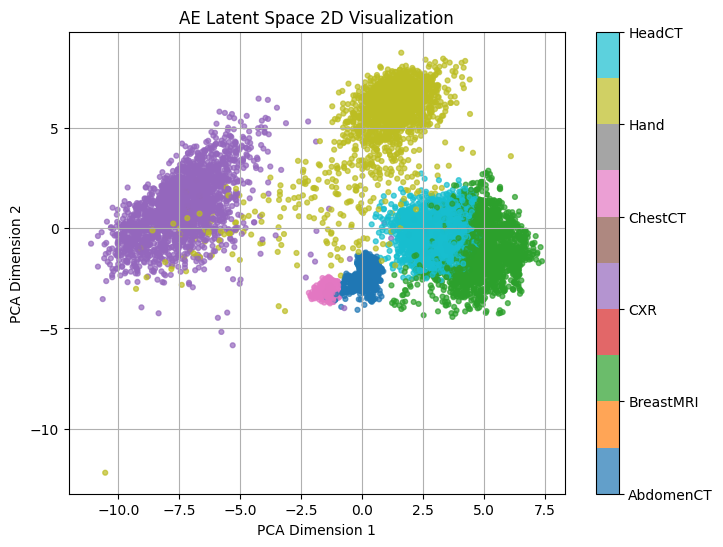

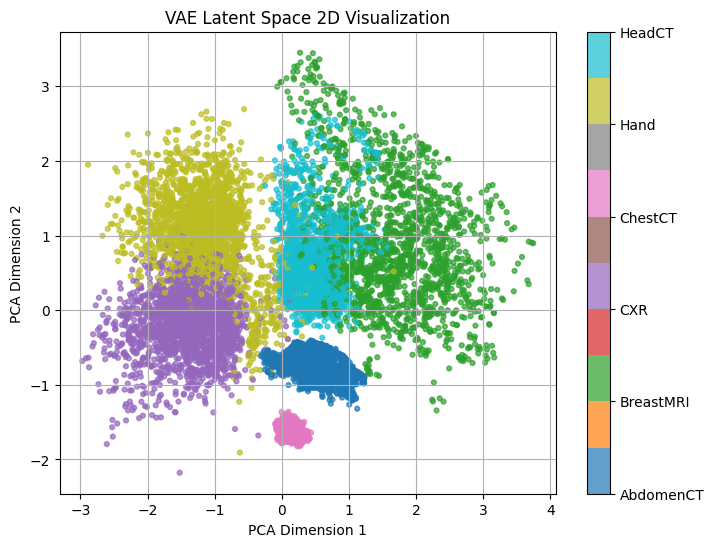

In [18]:
def plot_latent_2d(latents, labels, class_names, title):
    if latents.shape[1] > 2:
        reducer = PCA(n_components=2, random_state=SEED)
        latents_2d = reducer.fit_transform(latents)
        x_label = "PCA Dimension 1"
        y_label = "PCA Dimension 2"
    else:
        latents_2d = latents
        x_label = "Latent Dimension 1"
        y_label = "Latent Dimension 2"

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        latents_2d[:, 0],
        latents_2d[:, 1],
        c=labels,
        cmap="tab10",
        alpha=0.7,
        s=12
    )

    cbar = plt.colorbar(scatter)
    cbar.set_ticks(range(len(class_names)))
    cbar.set_ticklabels(class_names)

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True)
    plt.show()


plot_latent_2d(ae_latents, ae_latent_labels, class_names, "AE Latent Space 2D Visualization")
plot_latent_2d(vae_latents, vae_latent_labels, class_names, "VAE Latent Space 2D Visualization")

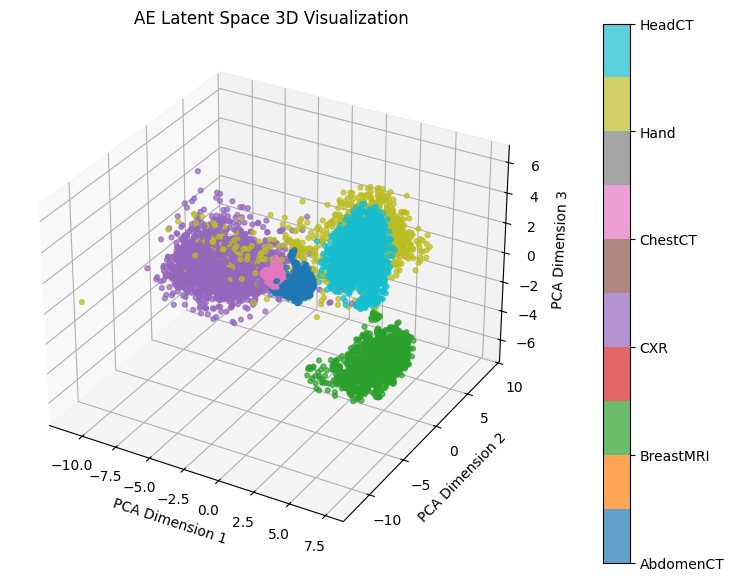

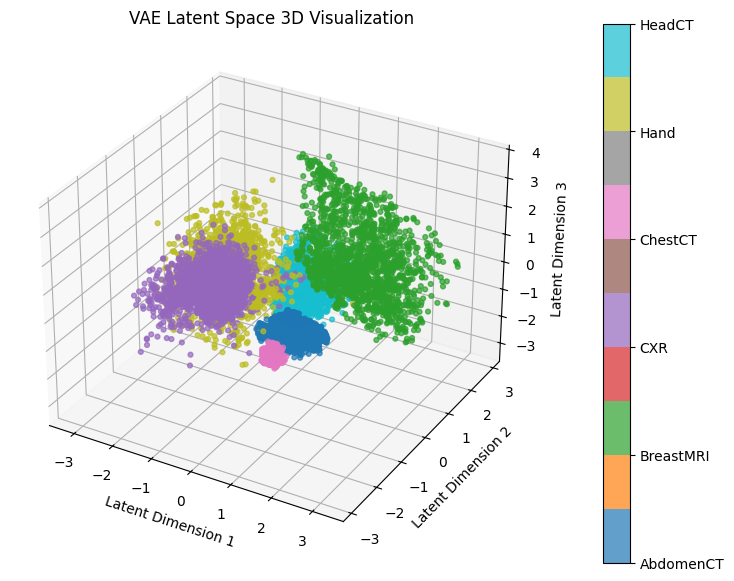

In [19]:
def plot_latent_3d(latents, labels, class_names, title):
    if latents.shape[1] > 3:
        reducer = PCA(n_components=3, random_state=SEED)
        latents_3d = reducer.fit_transform(latents)
        x_label = "PCA Dimension 1"
        y_label = "PCA Dimension 2"
        z_label = "PCA Dimension 3"
    elif latents.shape[1] == 3:
        latents_3d = latents
        x_label = "Latent Dimension 1"
        y_label = "Latent Dimension 2"
        z_label = "Latent Dimension 3"
    else:
        print("3D plot needs at least 3 latent dimensions.")
        return

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    scatter = ax.scatter(
        latents_3d[:, 0],
        latents_3d[:, 1],
        latents_3d[:, 2],
        c=labels,
        cmap="tab10",
        alpha=0.7,
        s=12
    )

    cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_ticks(range(len(class_names)))
    cbar.set_ticklabels(class_names)

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_zlabel(z_label)

    plt.show()


plot_latent_3d(ae_latents, ae_latent_labels, class_names, "AE Latent Space 3D Visualization")
plot_latent_3d(vae_latents, vae_latent_labels, class_names, "VAE Latent Space 3D Visualization")

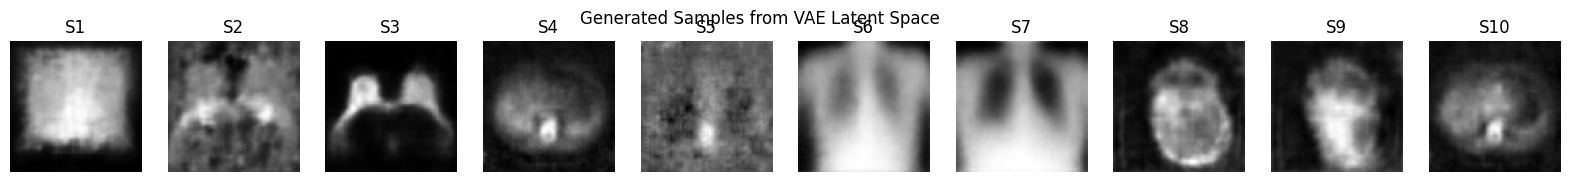

In [20]:
def generate_vae_samples(decoder, latent_dim=3, n=10):
    z_samples = np.random.normal(size=(n, latent_dim)).astype("float32")
    generated_images = decoder.predict(z_samples, verbose=0)

    plt.figure(figsize=(2 * n, 2))

    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(generated_images[i].squeeze(), cmap="gray")
        plt.title(f"S{i+1}")
        plt.axis("off")

    plt.suptitle("Generated Samples from VAE Latent Space")
    plt.show()


generate_vae_samples(vae_decoder, latent_dim=VAE_LATENT_DIM, n=10)

In [21]:
def add_noise(image, noise_factor=0.35):
    noise = noise_factor * tf.random.normal(shape=tf.shape(image))
    noisy_image = image + noise
    noisy_image = tf.clip_by_value(noisy_image, 0.0, 1.0)
    return noisy_image


def make_denoising_dataset(paths, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(
        lambda img, label: (add_noise(img), img),
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds


train_denoise_ds = make_denoising_dataset(train_paths, train_labels, training=True)
val_denoise_ds = make_denoising_dataset(val_paths, val_labels, training=False)

print("Denoising datasets are ready.")

Denoising datasets are ready.


In [22]:
denoising_ae, denoising_encoder, denoising_decoder = create_autoencoder(AE_LATENT_DIM)

denoising_history = denoising_ae.fit(
    train_denoise_ds,
    validation_data=val_denoise_ds,
    epochs=EPOCHS_DENOISING
)

Epoch 1/5
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.0140 - mse: 0.0140 - val_loss: 0.0084 - val_mse: 0.0084
Epoch 2/5
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 0.0078 - mse: 0.0078 - val_loss: 0.0073 - val_mse: 0.0073
Epoch 3/5
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 0.0070 - mse: 0.0070 - val_loss: 0.0068 - val_mse: 0.0068
Epoch 4/5
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 0.0066 - mse: 0.0066 - val_loss: 0.0065 - val_mse: 0.0065
Epoch 5/5
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - loss: 0.0063 - mse: 0.0063 - val_loss: 0.0063 - val_mse: 0.0063


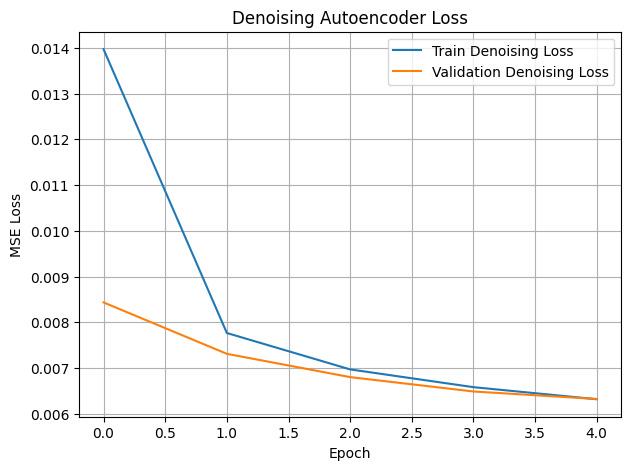

In [23]:
plt.figure(figsize=(7, 5))

plt.plot(denoising_history.history["loss"], label="Train Denoising Loss")
plt.plot(denoising_history.history["val_loss"], label="Validation Denoising Loss")

plt.title("Denoising Autoencoder Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

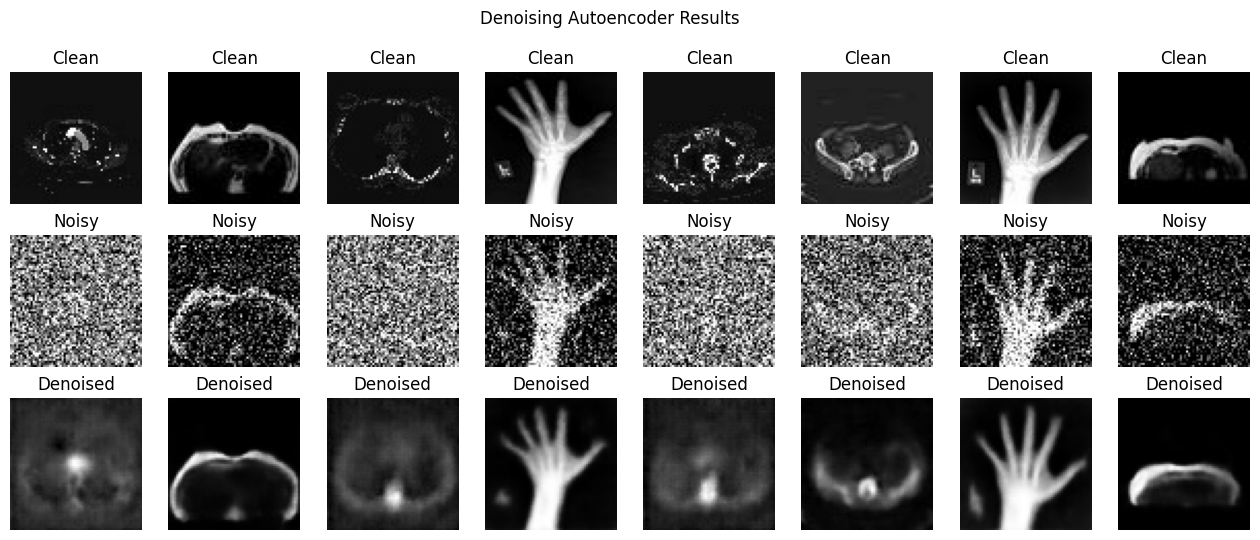

In [24]:
def show_denoising_results(model, denoise_dataset, n=8):
    noisy_images, clean_images = next(iter(denoise_dataset))
    denoised_images = model.predict(noisy_images, verbose=0)

    plt.figure(figsize=(2 * n, 6))

    for i in range(n):
        plt.subplot(3, n, i + 1)
        plt.imshow(clean_images[i].numpy().squeeze(), cmap="gray")
        plt.title("Clean")
        plt.axis("off")

        plt.subplot(3, n, i + 1 + n)
        plt.imshow(noisy_images[i].numpy().squeeze(), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(denoised_images[i].squeeze(), cmap="gray")
        plt.title("Denoised")
        plt.axis("off")

    plt.suptitle("Denoising Autoencoder Results")
    plt.show()


show_denoising_results(denoising_ae, val_denoise_ds, n=8)

In [25]:
def evaluate_denoising(model, denoise_dataset):
    noisy_mse_values = []
    denoised_mse_values = []

    noisy_ssim_values = []
    denoised_ssim_values = []

    for noisy_images, clean_images in denoise_dataset:
        denoised_images = model.predict(noisy_images, verbose=0)

        noisy_mse = tf.reduce_mean(tf.square(clean_images - noisy_images), axis=[1, 2, 3])
        denoised_mse = tf.reduce_mean(tf.square(clean_images - denoised_images), axis=[1, 2, 3])

        noisy_ssim = tf.image.ssim(clean_images, noisy_images, max_val=1.0)
        denoised_ssim = tf.image.ssim(clean_images, denoised_images, max_val=1.0)

        noisy_mse_values.extend(noisy_mse.numpy())
        denoised_mse_values.extend(denoised_mse.numpy())

        noisy_ssim_values.extend(noisy_ssim.numpy())
        denoised_ssim_values.extend(denoised_ssim.numpy())

    results = {
        "Noisy Input MSE": np.mean(noisy_mse_values),
        "Denoised Output MSE": np.mean(denoised_mse_values),
        "Noisy Input SSIM": np.mean(noisy_ssim_values),
        "Denoised Output SSIM": np.mean(denoised_ssim_values)
    }

    return results


denoising_results = evaluate_denoising(denoising_ae, val_denoise_ds)

print("Denoising Evaluation")
print("--------------------")
for metric, value in denoising_results.items():
    print(f"{metric}: {value:.6f}")

Denoising Evaluation
--------------------
Noisy Input MSE: 0.076514
Denoised Output MSE: 0.006321
Noisy Input SSIM: 0.145244
Denoised Output SSIM: 0.672397


In [26]:
save_dir = "/content/drive/MyDrive/DSAI490/medical-mnist/models"
os.makedirs(save_dir, exist_ok=True)

ae.save(os.path.join(save_dir, "autoencoder.keras"))
ae_encoder.save(os.path.join(save_dir, "ae_encoder.keras"))
ae_decoder.save(os.path.join(save_dir, "ae_decoder.keras"))

vae_encoder.save(os.path.join(save_dir, "vae_encoder.keras"))
vae_decoder.save(os.path.join(save_dir, "vae_decoder.keras"))

denoising_ae.save(os.path.join(save_dir, "denoising_autoencoder.keras"))

print("Models saved to:", save_dir)

Models saved to: /content/drive/MyDrive/DSAI490/medical-mnist/models


In [27]:
print("Final Experiment Summary")
print("========================")

print("\nDataset")
print("-------")
print("Total images:", len(image_paths))
print("Classes:", class_names)
print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))

print("\nAE vs VAE Reconstruction")
print("------------------------")
for metric, value in reconstruction_results.items():
    print(f"{metric}: {value:.6f}")

print("\nDenoising Results")
print("-----------------")
for metric, value in denoising_results.items():
    print(f"{metric}: {value:.6f}")

Final Experiment Summary

Dataset
-------
Total images: 58954
Classes: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']
Training images: 47163
Validation images: 11791

AE vs VAE Reconstruction
------------------------
AE MSE: 0.004583
VAE MSE: 0.015444
AE SSIM: 0.730033
VAE SSIM: 0.533465

Denoising Results
-----------------
Noisy Input MSE: 0.076514
Denoised Output MSE: 0.006321
Noisy Input SSIM: 0.145244
Denoised Output SSIM: 0.672397
